# Modelo Baseline: Regresión Lineal
En este notebook entrenaremos un modelo de regresión lineal simple para establecer un rendimiento base (baseline) en la predicción de la cantidad (`Amount`).

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuraciones de visualización
sns.set_theme(style="whitegrid")

## 1. Carga de los datos procesados
Cargamos los datos que preprocesamos y dividimos en el notebook anterior.

In [9]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (1669, 3)
Validation shape: (358, 3)
Test shape: (358, 3)


## 2. Feature Engineering Básico (Tratamiento de Fechas)
La columna `Date` por sí sola no es numérica, así que vamos a extraer características útiles como el día, mes, y día de la semana para que la regresión lineal pueda utilizarlas.

In [10]:
def process_features(df):
    df_copy = df.copy()
    # Convertir 'Date' a datetime
    df_copy['Date'] = pd.to_datetime(df_copy['Date'])
    
    # Extraer nuevas variables
    df_copy['Day'] = df_copy['Date'].dt.day
    df_copy['Month'] = df_copy['Date'].dt.month
    df_copy['DayOfWeek'] = df_copy['Date'].dt.dayofweek
    df_copy['IsWeekend'] = df_copy['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Eliminar la columna Date original ya que no se puede pasar a la regresión directamente
    df_copy = df_copy.drop(columns=['Date'])
    
    return df_copy

X_train_full = process_features(train_df)
X_val_full = process_features(val_df)
X_test_full = process_features(test_df)

X_train_full.head()

,Amount,Area,Day,Month,DayOfWeek,IsWeekend
0,-11.62,1,1,2,0,0
1,-5.00,2,1,2,0,0
2,-3.28,1,14,2,6,1
3,-37.67,3,16,2,1,0
4,-14.99,1,17,2,2,0


## 3. Separación de Variables Predictoras (X) y Target (y)
Separamos nuestra variable objetivo, `Amount`, de las variables predictoras.

In [11]:
target = 'Amount'

X_train = X_train_full.drop(columns=[target])
y_train = X_train_full[target]

X_val = X_val_full.drop(columns=[target])
y_val = X_val_full[target]

X_test = X_test_full.drop(columns=[target])
y_test = X_test_full[target]

## 4. Entrenamiento del Modelo Baseline
Instanciamos y entrenamos el modelo de SciKit-Learn.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Modelo entrenado.")
print("Intercept:", model.intercept_)
print("Coeficientes:", dict(zip(X_train.columns, model.coef_)))

Modelo entrenado.
Intercept: -37.62121418689114
Coeficientes: {'Area': np.float64(6.095954297991716), 'Day': np.float64(1.0794497742499025), 'Month': np.float64(-0.04128434568616594), 'DayOfWeek': np.float64(-0.8598134459591945), 'IsWeekend': np.float64(-3.4702270122557004)}


## 5. Evaluación del Modelo
Definimos una función para calcular y mostrar las métricas de error principales (MAE, RMSE) y el R2.

In [13]:
def evaluate_model(model, X, y, set_name=""):
    predictions = model.predict(X)
    
    mae = mean_absolute_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r2 = r2_score(y, predictions)
    
    print(f"--- Resultados para el conjunto de {set_name} ---")
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"R^2 Score: {r2:.4f}\n")
    
    return predictions

print("Evaluando en entrenamiento...")
y_pred_train = evaluate_model(model, X_train, y_train, "Train")

print("Evaluando en validación...")
y_pred_val = evaluate_model(model, X_val, y_val, "Validation")

Evaluando en entrenamiento...
--- Resultados para el conjunto de Train ---
MAE (Mean Absolute Error): 34.29
RMSE (Root Mean Squared Error): 61.10
R^2 Score: 0.0574

Evaluando en validación...
--- Resultados para el conjunto de Validation ---
MAE (Mean Absolute Error): 36.04
RMSE (Root Mean Squared Error): 105.84
R^2 Score: -0.0160



## 6. Visualización de los Resultados
Vamos a graficar los valores reales vs los predichos para el conjunto de validación. Al ser una regresión lineal sobre pocas variables, es probable que no capture la varianza completa.

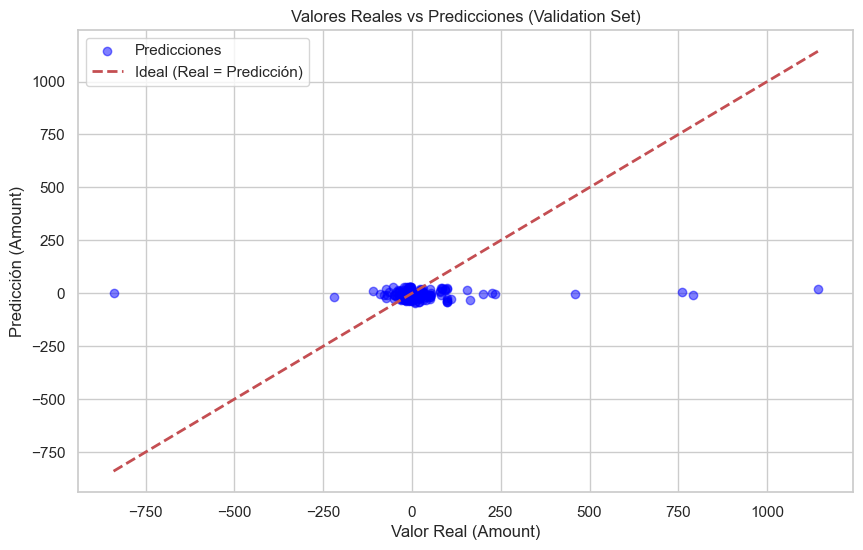

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred_val, alpha=0.5, color='blue', label='Predicciones')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Ideal (Real = Predicción)')
plt.xlabel('Valor Real (Amount)')
plt.ylabel('Predicción (Amount)')
plt.title('Valores Reales vs Predicciones (Validation Set)')
plt.legend()
plt.show()